# Mode 2 GPU backends — OpenMP-target vs OpenACC on Towradgi small

Mode 2 ('unified') can offload to the GPU through two back ends of the *same* kernels:

* **OpenMP target** — `nvc -mp=gpu` (the default), and
* **OpenACC** — `nvc -acc=gpu`, added by PR #188 (`-Dgpu_backend=openacc`).

They compile the identical `gpu/*.c` kernels through `gpu/gpu_omp_macros.h`; only the
offload model (and hence the reduction order / FP contraction the compiler emits) differs.
So this is the GPU-back-end analogue of the mode-1-vs-mode-2 notebook: same equations, not
bit-identical, and any difference is expected to be **roundoff seeded, then amplified
chaotically** by the wetting/drying flood.

Both runs here were produced from the **PR #188 branch** (the only place OpenACC exists), so
they are a clean back-end comparison — the develop-branch fixes (#199, #200) would shift both
back ends equally and do not affect their *difference*.

In [1]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import anuga

HERE = os.getcwd()
OUT  = os.path.join(HERE, 'MODEL_OUTPUTS')
SWW_OMP = os.path.join(OUT, 'towradgi_openmp.sww')     # nvc -mp=gpu
SWW_ACC = os.path.join(OUT, 'towradgi_openacc.sww')    # nvc -acc=gpu

## 1. Generating the two runs (two builds)

Unlike the mode-1-vs-mode-2 case (one build, `-mpm` flag), the two GPU back ends are
**separate builds**, so they cannot be produced in one notebook run. Build each and copy its
`.sww` aside (from the PR #188 branch):

```bash
# OpenMP-target
CC=$(which nvc) pip install --no-build-isolation -e . \
    -Csetup-args=-Dgpu_offload=true -Csetup-args=-Dgpu_backend=openmp -Csetup-args=-Dgpu_arch=cc120
OMP_NUM_THREADS=1 python run_small_towradgi.py -mpm 2 -go -ft 3600
cp MODEL_OUTPUTS/Towradgi_historic_flood.sww MODEL_OUTPUTS/towradgi_openmp.sww

# OpenACC (rm -rf the build dir first so meson re-reads gpu_backend)
CC=$(which nvc) pip install --no-build-isolation -e . \
    -Csetup-args=-Dgpu_offload=true -Csetup-args=-Dgpu_backend=openacc -Csetup-args=-Dgpu_arch=cc120
OMP_NUM_THREADS=1 python run_small_towradgi.py -mpm 2 -go -ft 3600
cp MODEL_OUTPUTS/Towradgi_historic_flood.sww MODEL_OUTPUTS/towradgi_openacc.sww
```


In [2]:
for p in (SWW_OMP, SWW_ACC):
    assert os.path.exists(p), f'missing {p} — build the two back ends and copy the .sww (see above)'
omp = anuga.SWW_plotter(SWW_OMP)
acc = anuga.SWW_plotter(SWW_ACC)
assert np.array_equal(omp.x, acc.x) and np.array_equal(omp.time, acc.time)
print(f'{omp.triangles.shape[0]:,} triangles, {len(omp.time)} output times (0 .. {omp.time[-1]:.0f} s)')

QUANTITIES = [('stage', 'stage', 'm'), ('xmom', 'x-momentum', 'm$^2$/s'),
              ('ymom', 'y-momentum', 'm$^2$/s'), ('depth', 'depth', 'm'),
              ('speed', 'speed', 'm/s')]

256,688 triangles, 31 output times (0 .. 3600 s)


## 2. OpenACC is deterministic

A GPU back end that is *not* bit-reproducible run-to-run would be a data race (a missed
`acc wait`). If a second OpenACC run is available, it must be bit-identical.

In [3]:
acc2_path = os.path.join(OUT, 'towradgi_openacc_run2.sww')
if os.path.exists(acc2_path):
    acc2 = anuga.SWW_plotter(acc2_path)
    d = np.abs(acc.stage - acc2.stage).max()
    print(f'OpenACC run 1 vs run 2: max|dStage| = {d:.3e}  '
          f'({"bitwise reproducible" if d == 0 else "NOT reproducible - investigate"})')
else:
    print('(no second OpenACC run present; skip determinism check)')

OpenACC run 1 vs run 2: max|dStage| = 0.000e+00  (bitwise reproducible)


## 3. When do the back ends diverge?

Max and RMS of `|OpenMP - OpenACC|` over the domain at each output time. Expect roundoff at
t=0 amplifying chaotically, with the same t=360 rain-ramp acceleration seen elsewhere.

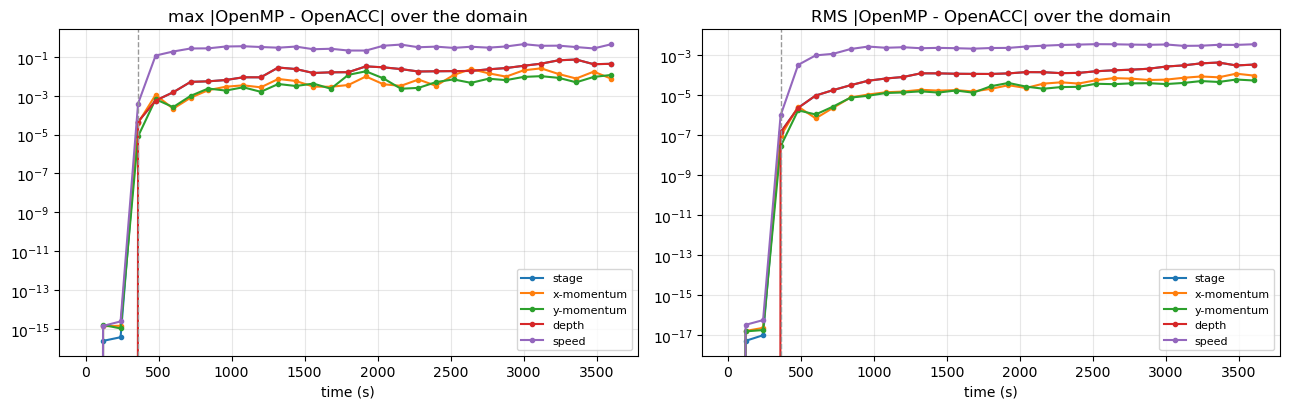

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for key, label, _ in QUANTITIES:
    d = np.abs(getattr(omp, key) - getattr(acc, key))
    ax[0].plot(omp.time, d.max(axis=1), marker='.', label=label)
    ax[1].plot(omp.time, np.sqrt((d**2).mean(axis=1)), marker='.', label=label)
for a, t in zip(ax, ['max', 'RMS']):
    a.axvline(360, color='0.6', ls='--', lw=1)
    a.set_yscale('log'); a.set_xlabel('time (s)'); a.grid(alpha=.3)
    a.set_title(f'{t} |OpenMP - OpenACC| over the domain')
    a.legend(fontsize=8)
fig.tight_layout()

## 4. Where are the differences? (final time)

Left: OpenMP flood depth (context, capped at 2 m so inland detail shows). Middle/right:
`|Dstage|` and `|Dspeed|` on a white->red log scale with cells below the noise floor masked.
As with mode 1 vs mode 2, the differences trace the flooded channels and wet/dry fronts.

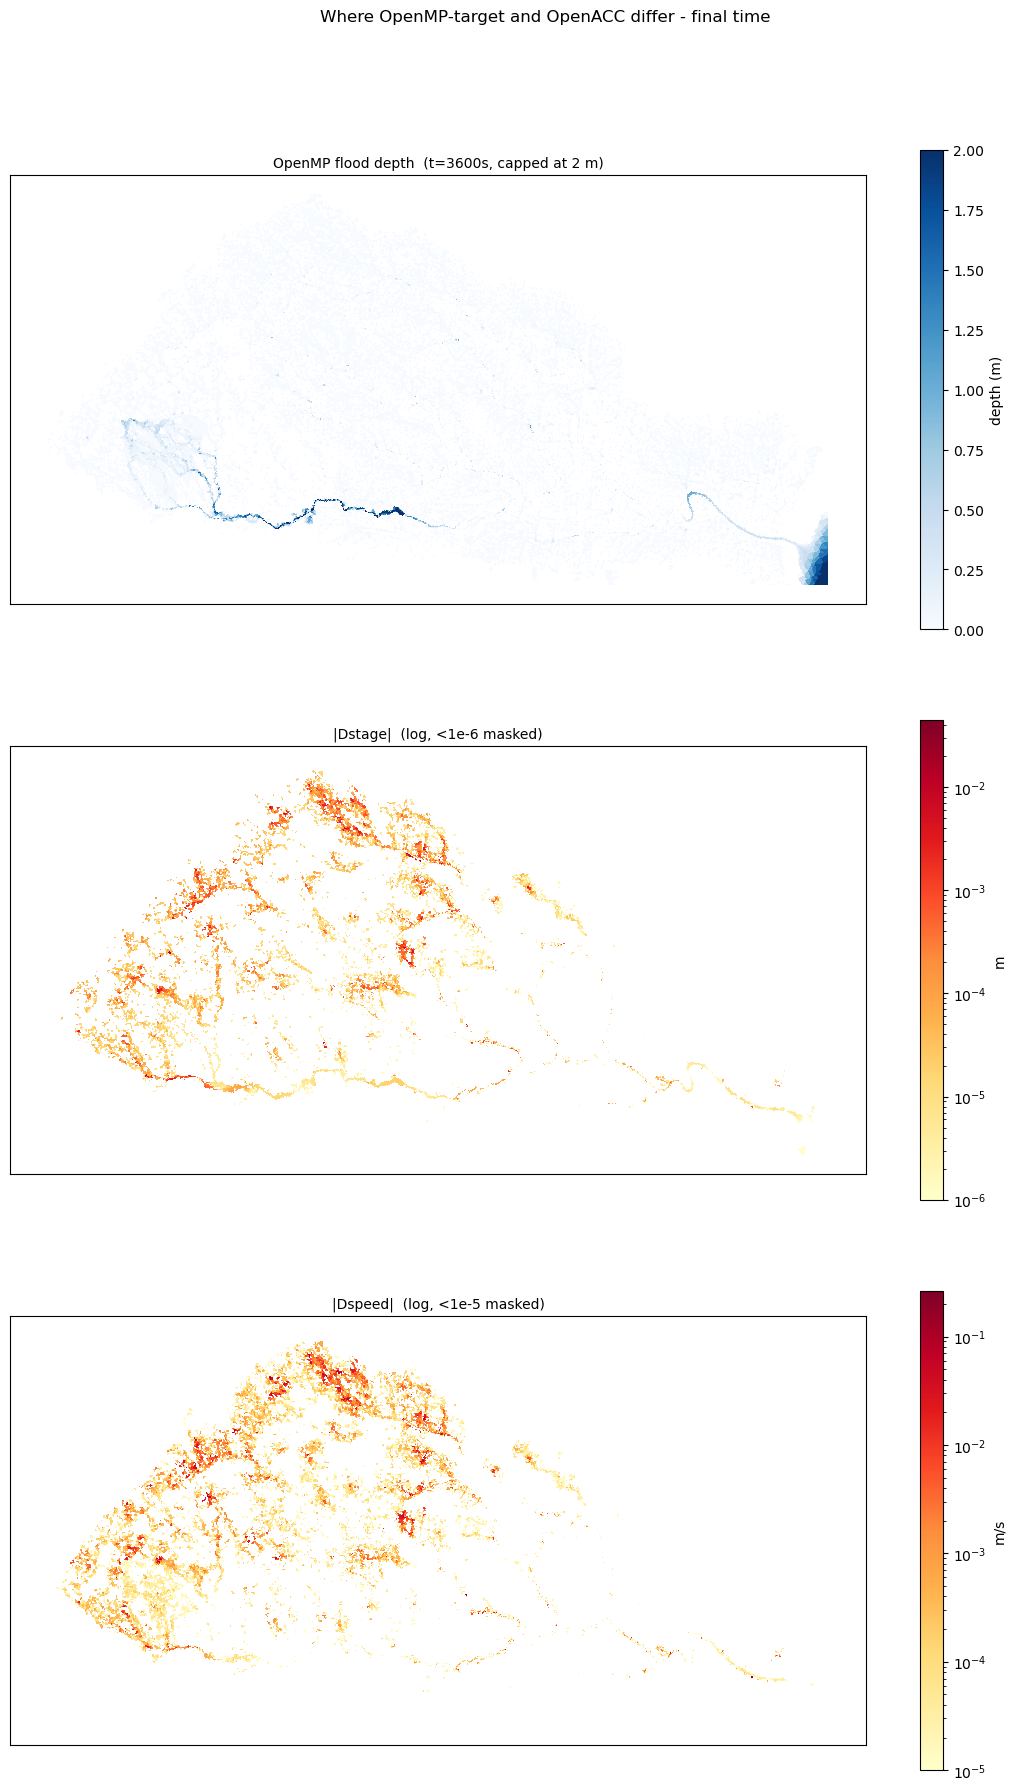

In [5]:
def wet_mask(p, ti, thresh=1e-3):
    return p.depth[ti] > thresh

def _white_cmap(name):
    cm = mpl.colormaps[name].copy(); cm.set_bad('white'); return cm

def diff_map(ax, values, title, cmap, label, norm=None, mask=None):
    omp.triang.set_mask(None)
    v = np.array(values, dtype=float)
    if mask is not None:
        v = np.where(mask, v, np.nan)
    ax.set_facecolor('white')
    kw = dict(norm=norm) if norm is not None else {}
    tpc = ax.tripcolor(omp.triang, facecolors=v, cmap=cmap, shading='flat', **kw)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    plt.colorbar(tpc, ax=ax, shrink=0.8, label=label)

def diff_only(p1, p2, key, ti, floor):
    d = np.abs(getattr(p1, key)[ti] - getattr(p2, key)[ti])
    keep = wet_mask(p1, ti) & (d >= floor)
    return np.where(keep, d, np.nan), (d[keep].max() if keep.any() else floor)

i = -1
STAGE_FLOOR, SPEED_FLOOR = 1e-6, 1e-5
dstage, smax = diff_only(omp, acc, 'stage', i, STAGE_FLOOR)
dspeed, vmax = diff_only(omp, acc, 'speed', i, SPEED_FLOOR)

fig, ax = plt.subplots(3, 1, figsize=(11, 18)); fig.set_facecolor('white')
diff_map(ax[0], np.where(wet_mask(omp, i), omp.depth[i], np.nan),
         f'OpenMP flood depth  (t={omp.time[i]:.0f}s, capped at 2 m)', _white_cmap('Blues'),
         'depth (m)', norm=mpl.colors.Normalize(vmin=0, vmax=2, clip=True))
diff_map(ax[1], dstage, '|Dstage|  (log, <1e-6 masked)', _white_cmap('YlOrRd'), 'm',
         norm=LogNorm(vmin=STAGE_FLOOR, vmax=smax, clip=True))
diff_map(ax[2], dspeed, '|Dspeed|  (log, <1e-5 masked)', _white_cmap('YlOrRd'), 'm/s',
         norm=LogNorm(vmin=SPEED_FLOOR, vmax=vmax, clip=True))
fig.suptitle('Where OpenMP-target and OpenACC differ - final time', y=1.02)
fig.tight_layout()

## 5. How the spatial difference develops

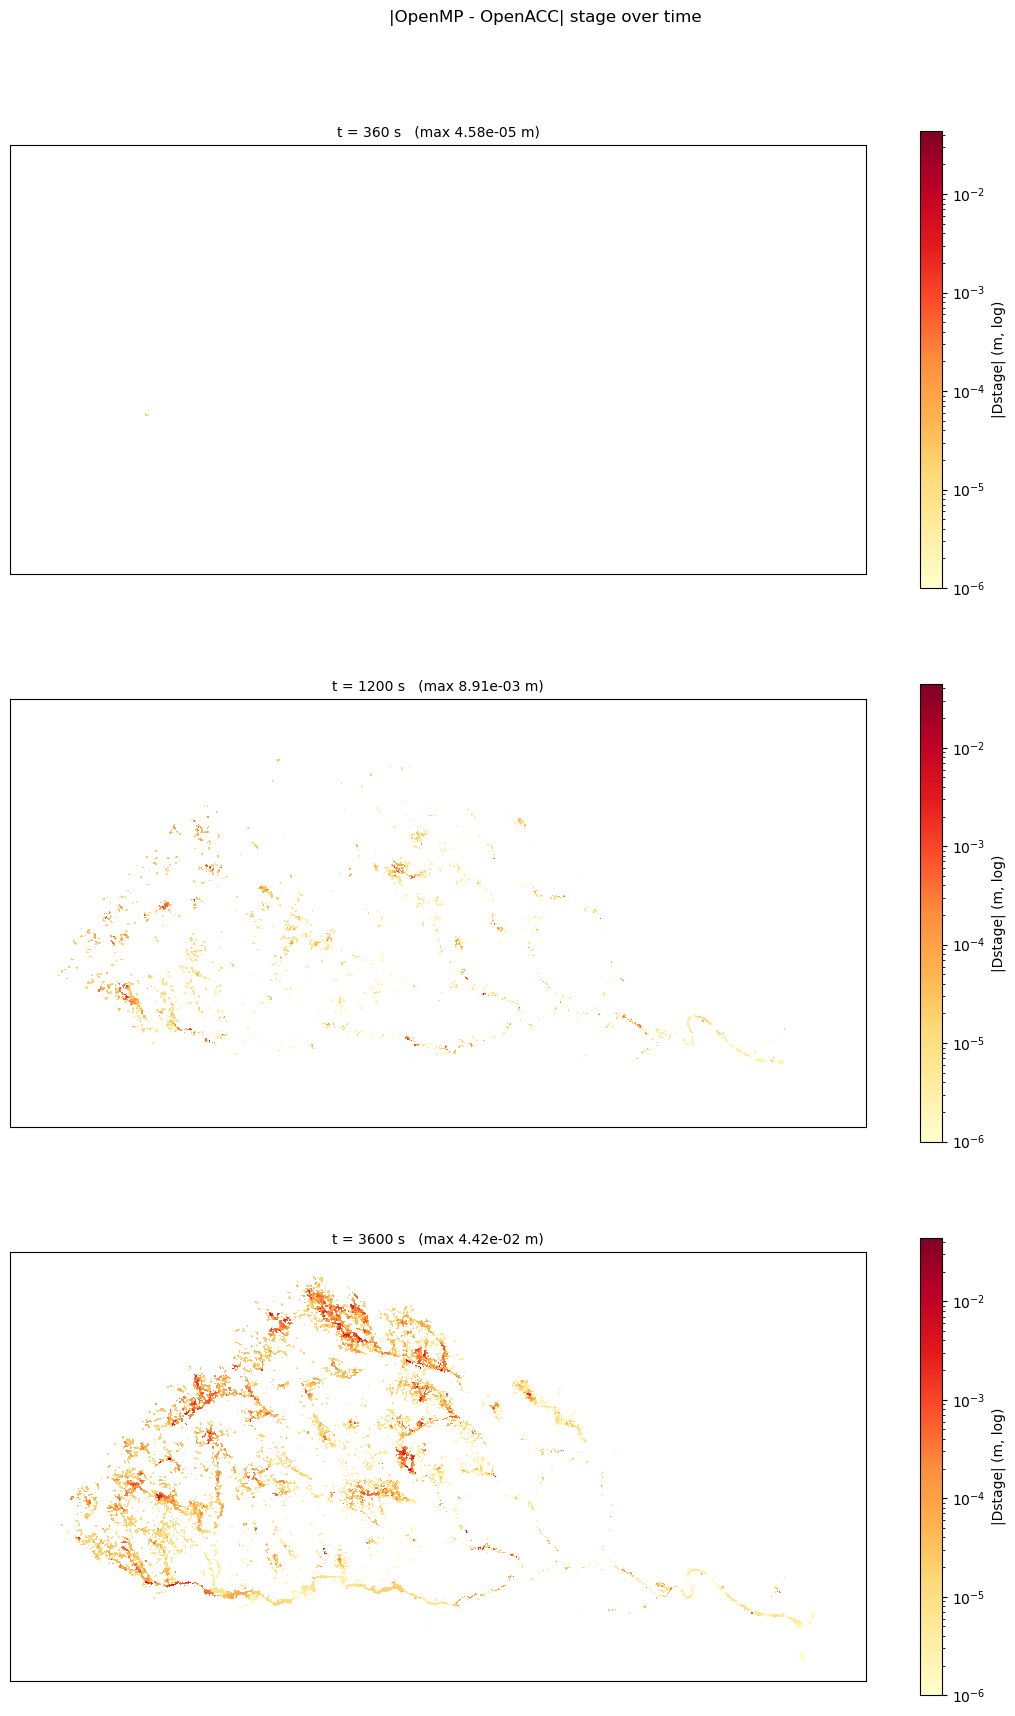

In [6]:
times_to_show = [t for t in (360.0, 1200.0, omp.time[-1]) if t in set(omp.time)]
fig, ax = plt.subplots(len(times_to_show), 1, figsize=(11, 5.8*len(times_to_show)))
fig.set_facecolor('white')
if len(times_to_show) == 1: ax = [ax]
STAGE_FLOOR = 1e-6
vmax = np.abs(omp.stage[-1] - acc.stage[-1])[wet_mask(omp, -1)].max()
norm = LogNorm(vmin=STAGE_FLOOR, vmax=vmax, clip=True)
cmap = _white_cmap('YlOrRd')
for a, t in zip(ax, times_to_show):
    ti = int(np.where(omp.time == t)[0][0])
    v, _ = diff_only(omp, acc, 'stage', ti, STAGE_FLOOR)
    omp.triang.set_mask(None); a.set_facecolor('white')
    tpc = a.tripcolor(omp.triang, facecolors=v, cmap=cmap, norm=norm, shading='flat')
    a.set_aspect('equal'); a.set_xticks([]); a.set_yticks([])
    a.set_title(f't = {t:.0f} s   (max {np.nanmax(v) if np.isfinite(np.nanmax(v)) else 0:.2e} m)',
                fontsize=10)
    plt.colorbar(tpc, ax=a, shrink=0.8, label='|Dstage| (m, log)')
fig.suptitle('|OpenMP - OpenACC| stage over time', y=1.01)
fig.tight_layout()

## Takeaways

* The two GPU back ends compile the same kernels; they differ only at **roundoff** (a
  different reduction order / FP contraction between `-mp=gpu` and `-acc=gpu`), amplified
  chaotically by the wetting/drying flood — same regime as mode 1 vs mode 2.
* **OpenACC is bit-reproducible** run-to-run (no data race in the single-async-queue design).
* The back ends agree with each other at least as tightly as legacy vs unified does — i.e.
  the OpenACC back end is numerically sound; the difference is the model's own chaotic
  sensitivity, not a back-end defect.
* Both `.sww` are from the PR #188 branch, so absolute magnitudes carry the #200 startup
  inlet deficit (present in both back ends equally); it cancels in this back-end-vs-back-end
  comparison.